In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_redundant=5,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, y_hat):
    eps = 1e-8
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))


In [4]:
class SimpleANN:
    def __init__(self, input_dim, hidden_dim, reg=None, lam=0.0):
        self.reg = reg
        self.lam = lam
        
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, 1) * 0.01
        self.b2 = np.zeros((1, 1))
    
    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2
    
    def compute_loss(self, y, y_hat):
        loss = binary_cross_entropy(y, y_hat)
        
        if self.reg == "l2":
            loss += (self.lam / (2 * len(y))) * (
                np.sum(self.W1**2) + np.sum(self.W2**2)
            )
        elif self.reg == "l1":
            loss += (self.lam / len(y)) * (
                np.sum(np.abs(self.W1)) + np.sum(np.abs(self.W2))
            )
        return loss
    
    def backward(self, X, y):
        m = len(y)
        
        dZ2 = self.A2 - y
        dW2 = (self.A1.T @ dZ2) / m
        db2 = np.mean(dZ2, axis=0, keepdims=True)
        
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.mean(dZ1, axis=0, keepdims=True)
        
        if self.reg == "l2":
            dW2 += (self.lam / m) * self.W2
            dW1 += (self.lam / m) * self.W1
        elif self.reg == "l1":
            dW2 += (self.lam / m) * np.sign(self.W2)
            dW1 += (self.lam / m) * np.sign(self.W1)
        
        return dW1, db1, dW2, db2
    
    def update(self, grads, lr):
        dW1, db1, dW2, db2 = grads
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2


In [5]:
def train(model, X_train, y_train, X_val, y_val, epochs=200, lr=0.1):
    train_losses, val_losses = [], []
    
    for _ in range(epochs):
        y_hat = model.forward(X_train)
        train_loss = model.compute_loss(y_train, y_hat)
        
        grads = model.backward(X_train, y_train)
        model.update(grads, lr)
        
        val_loss = model.compute_loss(y_val, model.forward(X_val))
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    return train_losses, val_losses


In [6]:
models = {
    "No Regularization": SimpleANN(20, 32),
    "L2 Regularization": SimpleANN(20, 32, reg="l2", lam=0.1),
    "L1 Regularization": SimpleANN(20, 32, reg="l1", lam=0.01)
}

history = {}

for name, model in models.items():
    history[name] = train(model, X_train, y_train, X_val, y_val)


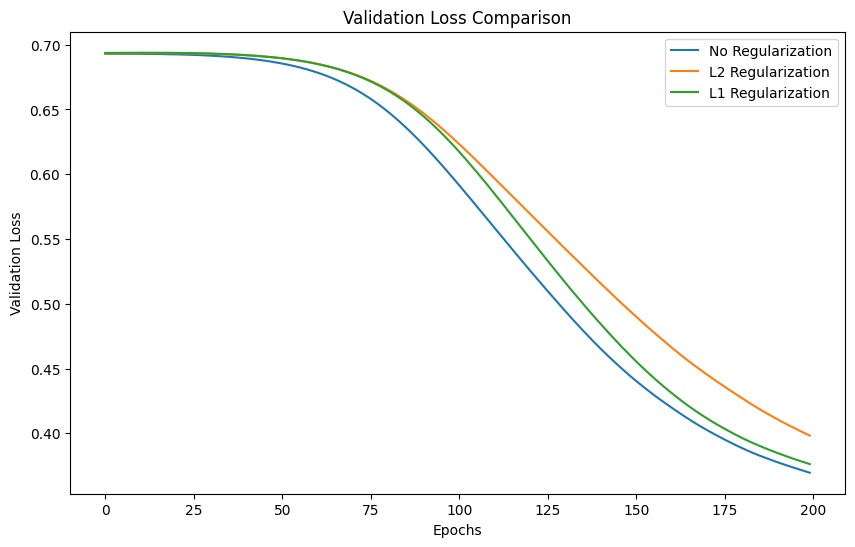

In [7]:
plt.figure(figsize=(10,6))

for name, (train_l, val_l) in history.items():
    plt.plot(val_l, label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()


In [8]:
for name, model in models.items():
    l2_norm = np.sqrt(np.sum(model.W1**2) + np.sum(model.W2**2))
    l1_norm = np.sum(np.abs(model.W1)) + np.sum(np.abs(model.W2))
    print(f"{name}: L2-norm={l2_norm:.3f}, L1-norm={l1_norm:.3f}")


No Regularization: L2-norm=2.303, L1-norm=30.788
L2 Regularization: L2-norm=2.105, L1-norm=27.653
L1 Regularization: L2-norm=2.257, L1-norm=28.860
